#### Lets do the analytics with the help of pandas, sql and matplotlib


In [64]:
### Libraries we will be using ! 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


### Connecting to the sql server using Docker




In [65]:
import psycopg2
connection = psycopg2.connect(
    host="localhost",
    port=5432,
    database="postgres",   # DB name
    user="postgres",       # DB user
    password="Suz@ljune13" # DB password
)


In [66]:
data = pd.read_sql('select * from cleaned where "Age" > 12;', connection)
data.head(5)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_37961/2023419232.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql('select * from cleaned where "Age" > 12;', connection)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741236,0.835985,725.10,47.777393,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007430,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


### We will be analyzing the data with the help of SQL and create some meaningful images with the help of Matplotlib
---

### 1. Average calories burned per workout type

In [67]:
query = """
select ROUND(AVG("Calories_Burned"):: numeric, 2), "Workout_Type"
from cleaned
group by "Workout_Type"
"""
average_calories = pd.read_sql(query, connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_37961/3323467537.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  average_calories = pd.read_sql(query, connection)


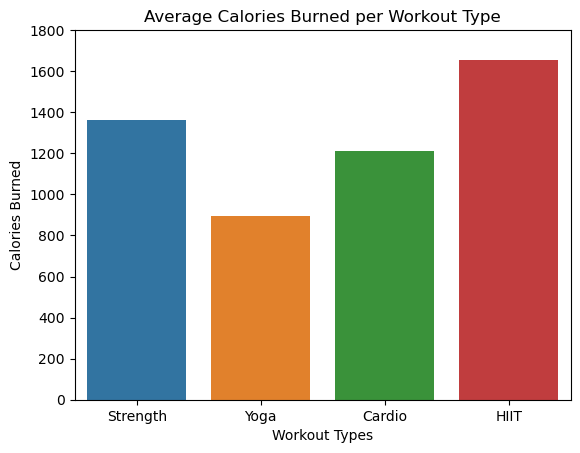

In [68]:
## Plotting average calories per workout 
sns.barplot(x = 'Workout_Type', y = 'round', data = average_calories, hue = 'Workout_Type' )
plt.ylim(0, 1800)
plt.xlabel("Workout Types")
plt.ylabel("Calories Burned")
plt.title("Average Calories Burned per Workout Type")
plt.show()


### As seen from the graph HIIT burns more calories whereas yoga burns less calories compared to other three!
---
### 2. Distribution of BMI in the dataset


In [69]:
query = """
with age_category as (
	select *,
	case 
		when "Age" >= 18 and "Age" <= 35 then 'Young Adults'
		when "Age" >=36 and "Age" <= 55 then 'Middle Age'
		else 'Older Adults'
	end as Age_Category
	from cleaned

)

select ROUND(AVG("BMI"):: numeric,2), Age_Category
from age_category
group by Age_category 
"""
bmi_distribution = pd.read_sql(query, connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_37961/2174608508.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  bmi_distribution = pd.read_sql(query, connection)


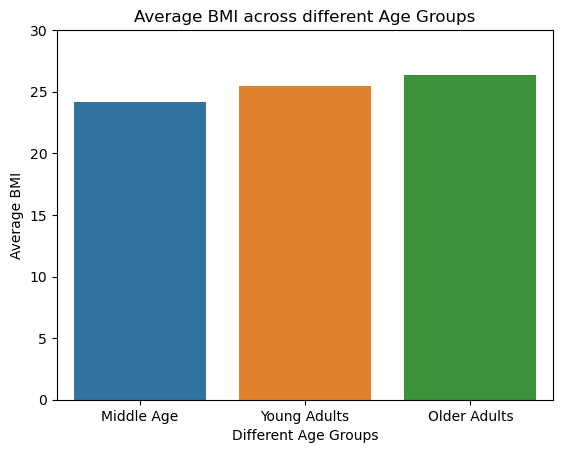

In [70]:
### Plotting the average distribution of the bmi across different age groups 
sns.barplot(x = 'age_category', y = 'round', data = bmi_distribution, hue = 'age_category')
plt.xlabel("Different Age Groups")
plt.ylabel("Average BMI")
plt.ylim(0,30)
plt.title("Average BMI across different Age Groups")
plt.show()

### As seen from the graph the average bmi across the different age groups are more or less similar to one other
---
### The Top 10 highest calorie-burning exercises?

In [71]:
query = """

with top_workout as (
	select "Name of Exercise", ROUND(AVG("Burns Calories (per 30 min)"):: numeric ,2) as Average_Calories,
	rank() over ( order by AVG("Burns Calories (per 30 min)") desc ) as Rank_Total
	from cleaned
	group by "Name of Exercise"
)


select * from top_workout
limit 10;
"""

top_ten = pd.read_sql(query, connection)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_37961/3784667097.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_ten = pd.read_sql(query, connection)


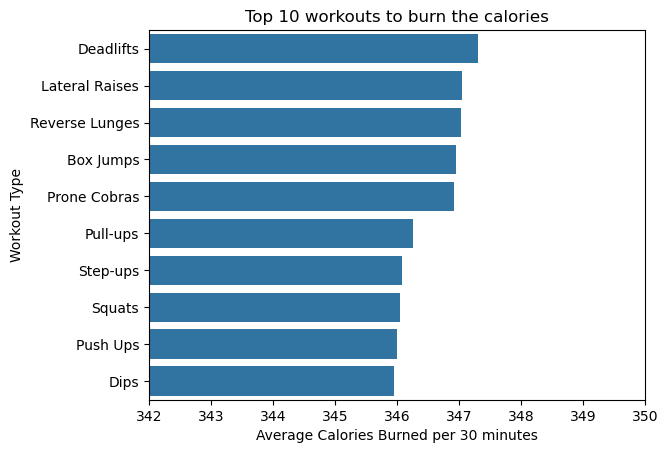

In [72]:
### Plotting the graph 
sns.barplot(x = 'average_calories', y = 'Name of Exercise', data = top_ten)
plt.xlim(342,350)
plt.xlabel("Average Calories Burned per 30 minutes")
plt.ylabel("Workout Type")
plt.title("Top 10 workouts to burn the calories")
plt.show()

### As seen from the graph, deadlifts burn the most calories in 30 minutes compared to other workoouts!
---
### Does Workout Frequency affects the Avg Calories Burned in a single session ?!

In [73]:
query = """with workout_frequency as (
	select *,
	case
		when "Workout_Frequency (days/week)" < 2.0 then 'Rare'
		when "Workout_Frequency (days/week)"  between 2.0 and 3.0 then 'Moderate'
		when "Workout_Frequency (days/week)" between 3.0 and 5.0 then 'Active'
		else 'Very_Active'
		
	end as Users_Commitment
	from cleaned
	
),

calories_burned_in_hour as(

	select Users_Commitment,  ROUND(AVG("Calories_Burned" / "Session_Duration (hours)")::numeric, 2) as Calories_Per_Frequency
	from workout_frequency
	group by Users_Commitment
)

select * from calories_burned_in_hour
order by calories_per_frequency desc
"""

workout_frequency = pd.read_sql(query, connection)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_37961/3474202319.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  workout_frequency = pd.read_sql(query, connection)


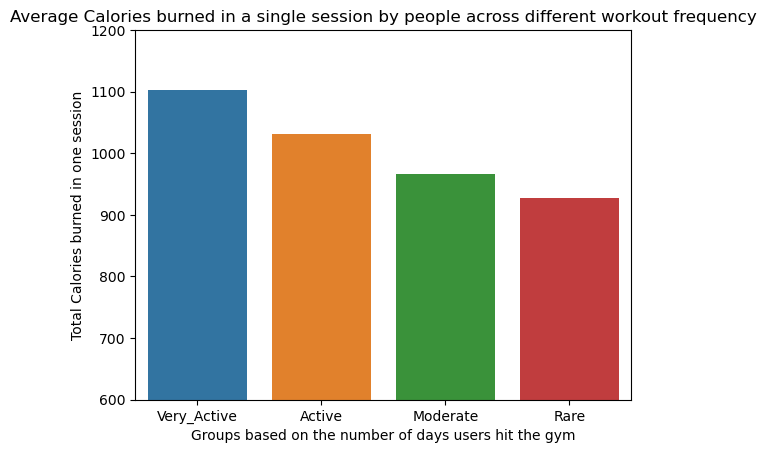

In [74]:
### Plotting the diagram 
sns.barplot(x = 'users_commitment', y = 'calories_per_frequency', data = workout_frequency, hue = 'users_commitment')
plt.xlabel("Groups based on the number of days users hit the gym")
plt.ylabel("Total Calories burned in one session")
plt.ylim(600,1200)
plt.title("Average Calories burned in a single session by people across different workout frequency")
plt.show()

### As seen from the graph, users who are very active in the gym tend to burn more calories in a single session compared to the ones who are very rare in the gym 
---
### What are the top 5 workouts for the Beginner Category based on their experience Level 

In [75]:
query = """
with experience_division as (
	select *, 
	case
		when "Experience_Level" < 1.5 then 'Beginner'
		when "Experience_Level" between 1.5 and 2.5 then 'Intermediate'
		else 'Advanced'
	end as Experience_Level
	from cleaned
	
),

begineer_difficulty as (
	 select "Name of Exercise", "Target Muscle Group", Experience_Level
	 from experience_division
	 where Experience_Level = 'Beginner'
	
)

select 
	"Name of Exercise",
	count(*) as Total
from begineer_difficulty 
group by "Name of Exercise"
order by Total desc
limit 10;"""

beginner_experience = pd.read_sql(query,connection)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_37961/955238226.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  beginner_experience = pd.read_sql(query,connection)


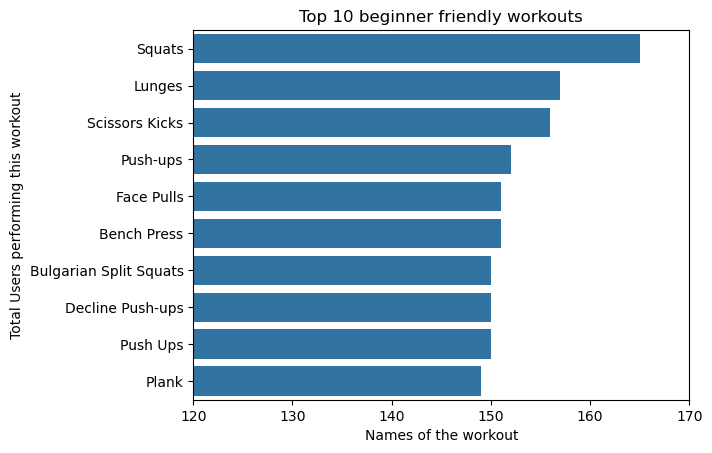

In [76]:
sns.barplot(x = 'total', y = 'Name of Exercise', data = beginner_experience)
plt.title("Top 10 beginner friendly workouts")
plt.ylabel("Total Users performing this workout")
plt.xlabel("Names of the workout")
plt.xlim(120,170)
plt.show()

### As seen from the graph Squats is the most followed workout among Beginners followed by Lunges and Scissors Kicks
---

### Exercise Preferences for each BMI Group & Cardiovascular Response by BMI Group

In [77]:
query = """



with BMI_calc as (
	select "BMI", "Resting_BPM","Name of Exercise", "Avg_BPM",
	case 
		when "BMI" < 18.5 then 'UnderWeight'
		when "BMI" between 18.5 and 24.9 then 'Normal/Healthy Weight'
		when "BMI" between 25 and 29.9 then 'Overweight'
		else 'Obesity'
	end as BMI_Category
	from cleaned
	
), 

common_workout as (
	select "Name of Exercise", 
	BMI_Category,
	count(*) as Most_Followed
	from BMI_calc
	group by "Name of Exercise", BMI_Category
), 
ranked_workouts as (
	select *,
	row_number() over (partition by BMI_Category order by Most_Followed desc) as rank
	from common_workout
	
), 

bpm as (
	select BMI_Category, 
	ROUND(AVG("Avg_BPM" - "Resting_BPM")::numeric, 2) as BPM
	from BMI_calc
	group by BMI_Category
	
)


select r.BMI_Category, r.rank, b.BPM as Average_Heart_Rate_Increase , r."Name of Exercise" , r.Most_Followed as User_count

from ranked_workouts as r
join bpm as b 
on r.BMI_Category = b.BMI_Category
where r.rank = 1


"""

exercise_bmi = pd.read_sql(query, connection)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_37961/1571907006.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exercise_bmi = pd.read_sql(query, connection)


In [78]:
exercise_bmi.head(5)

,bmi_category,rank,average_heart_rate_increase,Name of Exercise,user_count
0,Normal/Healthy Weight,1,81.38,Deadlift,168
1,Obesity,1,83.05,Plyo Squats,101
2,Overweight,1,80.77,Frog Jumps,110
3,UnderWeight,1,80.98,Decline Push-ups,76


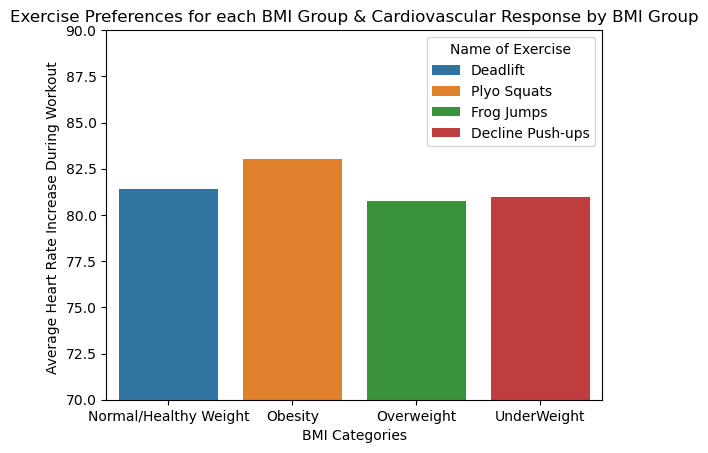

In [79]:
### Visualizing the data

sns.barplot(x = 'bmi_category', y = 'average_heart_rate_increase', hue = 'Name of Exercise', data = exercise_bmi)
plt.ylim(70,90)
plt.xlabel("BMI Categories")
plt.ylabel("Average Heart Rate Increase During Workout ")
plt.title("Exercise Preferences for each BMI Group & Cardiovascular Response by BMI Group")
plt.show()

### As we can see from the graph all the workouts shows the BMI increase of ~80-83 BPM which indicates very intense workouts. The workouts are the most followed workouts in each BMI Category. Overall the maximum efforts shown by each BMI group are more or less similar.
---